In [2]:
from sklearn.metrics import classification_report ## performance evaluation of the model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

In [3]:
## read the dataset
from google.colab import files
files.upload()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


{'Social_Network_Ads.csv': b'User ID,Gender,Age,EstimatedSalary,Purchased\r\n15624510,Male,19,19000,0\r\n15810944,Male,35,20000,0\r\n15668575,Female,26,43000,0\r\n15603246,Female,27,57000,0\r\n15804002,Male,19,76000,0\r\n15728773,Male,27,58000,0\r\n15598044,Female,27,84000,0\r\n15694829,Female,32,150000,1\r\n15600575,Male,25,33000,0\r\n15727311,Female,35,65000,0\r\n15570769,Female,26,80000,0\r\n15606274,Female,26,52000,0\r\n15746139,Male,20,86000,0\r\n15704987,Male,32,18000,0\r\n15628972,Male,18,82000,0\r\n15697686,Male,29,80000,0\r\n15733883,Male,47,25000,1\r\n15617482,Male,45,26000,1\r\n15704583,Male,46,28000,1\r\n15621083,Female,48,29000,1\r\n15649487,Male,45,22000,1\r\n15736760,Female,47,49000,1\r\n15714658,Male,48,41000,1\r\n15599081,Female,45,22000,1\r\n15705113,Male,46,23000,1\r\n15631159,Male,47,20000,1\r\n15792818,Male,49,28000,1\r\n15633531,Female,47,30000,1\r\n15744529,Male,29,43000,0\r\n15669656,Male,31,18000,0\r\n15581198,Male,31,74000,0\r\n15729054,Female,27,137000,1\r\n1

In [4]:
df = pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [6]:
## goal: it is to predict the Purchased feature
df.Purchased.value_counts()

## 0: does not purchase
## 1: the client purchases the item

## comment: the data is imbalanced, therefore without calibration the model is going to learn the most popular label

,count
Purchased,
0,257
1,143


In [7]:
df.Gender.value_counts()

,count
Gender,
Female,204
Male,196


In [10]:
df_numerical = df.select_dtypes(include=['int64', 'float64']).drop('User ID', axis=1)
df_numerical

numerical_variables = ["Age", "EstimatedSalary"]
for feature in numerical_variables:
  fig = px.histogram(df, feature, color = "Purchased", facet_row = "Purchased",histnorm = "probability")
  fig.show()

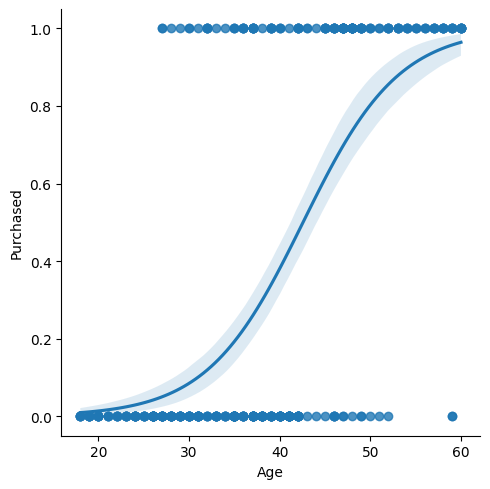

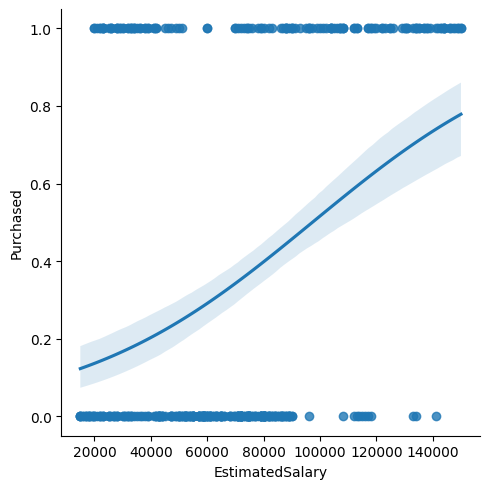

In [12]:
numerical_variables = ["Age", "EstimatedSalary"]
for feature in numerical_variables:
  sns.lmplot(data=df, x=feature, y="Purchased",logistic = True)

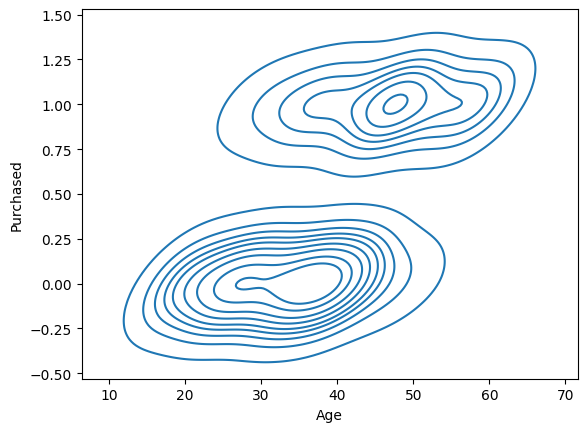

In [13]:
## Age vs purchase again
sns.kdeplot(x = "Age", y = "Purchased", data = df)
plt.show()

In [14]:
## EDA is finished

## step 1: choosing X and y
## step 2: train test split (here I need to be sure both genders are in the train set)
## step 3: imputation of the nans with the mean
## step 4: scaler transformation + dummification
## step 5: fit the model
## step 6: evaluate

In [16]:
target_variable = "Purchased"
X = df.drop(target_variable, axis =1).drop(columns = "User ID")
y = df[target_variable]
display(X)

,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000
...,...,...,...
395,Female,46,41000
396,Male,51,23000
397,Female,50,20000
398,Male,36,33000


In [56]:
numeric_features = ["Age", "EstimatedSalary"]
categorical_features = ["Gender"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, stratify = y, random_state = 42)


In [58]:
y_train.value_counts()/len(y_train)

,count
Purchased,
0,0.643333
1,0.356667


In [59]:
y.value_counts()/len(y)

,count
Purchased,
0,0.6425
1,0.3575


In [60]:
numeric_features

['Age', 'EstimatedSalary']

In [61]:
categorical_features

['Gender']

In [62]:
X_train

,Gender,Age,EstimatedSalary
352,Female,42,90000
311,Male,39,96000
85,Female,31,118000
179,Female,31,34000
235,Male,46,79000
...,...,...,...
4,Male,19,76000
323,Female,48,30000
314,Female,39,79000
170,Male,21,88000


In [63]:
X_test

,Gender,Age,EstimatedSalary
315,Female,39,75000
349,Male,38,61000
358,Male,40,71000
200,Male,35,39000
265,Female,42,108000
...,...,...,...
127,Male,26,32000
209,Female,46,22000
74,Male,32,18000
122,Female,40,75000


In [65]:
## Preprocessor pipeline

numeric_transformer = Pipeline(steps = [("imputer", SimpleImputer(strategy="mean")),
                                       ("scaler", StandardScaler())
                                       ])

#categorical_transformer = Pipeline(steps=[
 #   ('imputer', SimpleImputer(strategy='most_frequent')),
 #   ('onehot', OneHotEncoder(drop = "first"))
#])

categorical_transformer = OneHotEncoder(drop = "first") # same in dummification

preprocessor = ColumnTransformer(
            transformers = [("numerical", numeric_transformer, numeric_features),
                            ("categorical", categorical_transformer, categorical_features)]
)

In [66]:
## preprocessing step

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [53]:
X_train

array([[ 0.45809581,  0.54309037,  0.        ],
       [ 0.17532062,  0.71372445,  1.        ],
       [-0.57874655,  1.33938275,  0.        ],
       [-0.57874655, -1.04949441,  0.        ],
       [ 0.83512939,  0.23026122,  1.        ],
       [-1.23855533,  0.51465135,  0.        ],
       [-1.61558892, -1.36232356,  0.        ],
       [-0.01319618,  2.13567514,  0.        ],
       [-0.76726335, -0.28164103,  1.        ],
       [ 2.06048855,  0.48621234,  0.        ],
       [ 2.15474694, -0.8219823 ,  1.        ],
       [-0.20171297,  0.0027491 ,  0.        ],
       [ 1.30642138,  2.13567514,  0.        ],
       [-1.61558892,  0.42933431,  1.        ],
       [ 0.17532062, -0.8219823 ,  1.        ],
       [-0.10745457,  1.56689487,  0.        ],
       [-0.76726335,  2.19255317,  1.        ],
       [ 0.08106222, -0.56603117,  1.        ],
       [ 1.49493817,  0.31557826,  0.        ],
       [-1.05003854, -1.16325046,  1.        ],
       [ 1.96623015,  2.07879711,  1.   

In [68]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [70]:
## fit the model

classifier = LogisticRegression()
classifier.fit(X_train,y_train)

LogisticRegression()

In [72]:
## calculate the predictions
pred_train = classifier.predict(X_train)
display(pred_train)

pred_test = classifier.predict(X_test)#
display(pred_test)

array([1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0])

In [73]:
prob_train = classifier.predict_proba(X_train) ## these are the true predictions of the model
display(prob_train)

prob_test = classifier.predict_proba(X_test)
display(prob_test)

array([[0.4084746 , 0.5915254 ],
       [0.43081138, 0.56918862],
       [0.71221822, 0.28778178],
       [0.97827162, 0.02172838],
       [0.24618039, 0.75381961],
       [0.96562228, 0.03437772],
       [0.99839097, 0.00160903],
       [0.21678271, 0.78321729],
       [0.95118656, 0.04881344],
       [0.02256885, 0.97743115],
       [0.06317571, 0.93682429],
       [0.84729641, 0.15270359],
       [0.01567611, 0.98432389],
       [0.98095772, 0.01904228],
       [0.83010592, 0.16989408],
       [0.40375257, 0.59624743],
       [0.49127885, 0.50872115],
       [0.81449831, 0.18550169],
       [0.08806909, 0.91193091],
       [0.99054917, 0.00945083],
       [0.0029846 , 0.9970154 ],
       [0.70357801, 0.29642199],
       [0.14170635, 0.85829365],
       [0.62007126, 0.37992874],
       [0.98282258, 0.01717742],
       [0.81851795, 0.18148205],
       [0.98408319, 0.01591681],
       [0.5575096 , 0.4424904 ],
       [0.3981352 , 0.6018648 ],
       [0.8644641 , 0.1355359 ],
       [0.

array([[0.68126882, 0.31873118],
       [0.75660448, 0.24339552],
       [0.59408943, 0.40591057],
       [0.92454641, 0.07545359],
       [0.27053404, 0.72946596],
       [0.68757305, 0.31242695],
       [0.70871286, 0.29128714],
       [0.8679515 , 0.1320485 ],
       [0.00934969, 0.99065031],
       [0.95937744, 0.04062256],
       [0.00653835, 0.99346165],
       [0.89026423, 0.10973577],
       [0.92572663, 0.07427337],
       [0.75660448, 0.24339552],
       [0.90333554, 0.09666446],
       [0.18831419, 0.81168581],
       [0.67140767, 0.32859233],
       [0.68802054, 0.31197946],
       [0.8853167 , 0.1146833 ],
       [0.00820467, 0.99179533],
       [0.61190222, 0.38809778],
       [0.89183073, 0.10816927],
       [0.95808649, 0.04191351],
       [0.06942814, 0.93057186],
       [0.50759288, 0.49240712],
       [0.91498454, 0.08501546],
       [0.10447621, 0.89552379],
       [0.65909534, 0.34090466],
       [0.94133986, 0.05866014],
       [0.39451382, 0.60548618],
       [0.

In [74]:
## performance metric: accuracy

print("accuracy on the train set", accuracy_score(y_train, pred_train))
print("accuracy on the test set", accuracy_score(y_test, pred_test))

## the model overfitted a bit but nothing dangerous

accuracy on the train set 0.8566666666666667
accuracy on the test set 0.81


In [75]:
print(classification_report(y_train, pred_train))
print(classification_report(y_test, pred_test))

## precision is the number of times of that the model was right in calculating the predictions
## Precision_0 = T0s /(0s model), Precision_1 = T1s /(1s model)
## Recall_0 = T0s /(0s dataset), ## Recall_1 = T1s /(1s dataset)

## conclusion: the model correctly learns in the same proportion which means that when it redicts a 0 or a 1 statistically it predicts well
## on the train set 86% against 81% on the test set
## however the model learns more to recognize 0s from the dataset that 1s: this is reflected even more on the test set
## the reason for that is the imbalance: the model sees mores 0s than 1s in the train set


## depending of the business/product requirements we must define which class is privileged on the learning task.
## in case this label is class 1 which means true customers than we should increase the number of 1s samples in the train set.

              precision    recall  f1-score   support

           0       0.86      0.93      0.89       193
           1       0.86      0.72      0.78       107

    accuracy                           0.86       300
   macro avg       0.86      0.83      0.84       300
weighted avg       0.86      0.86      0.85       300

              precision    recall  f1-score   support

           0       0.81      0.92      0.86        64
           1       0.81      0.61      0.70        36

    accuracy                           0.81       100
   macro avg       0.81      0.77      0.78       100
weighted avg       0.81      0.81      0.80       100



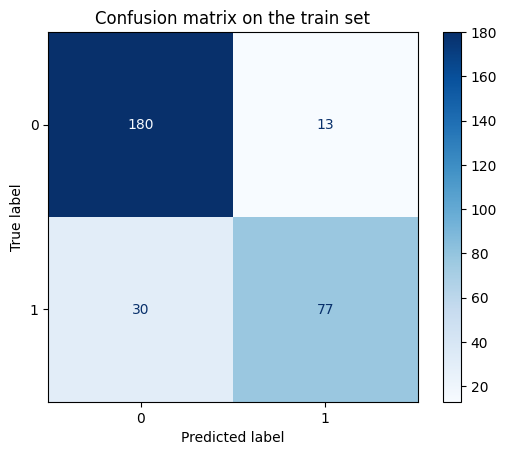

In [76]:
## confusion matrices

_, ax = plt.subplots()
ax.set(title = "Confusion matrix on the train set")
ConfusionMatrixDisplay.from_estimator(classifier, X_train, y_train, ax = ax, cmap = "Blues")
plt.show()

In [80]:
## train set

TP = 77
TN= 180
FN = 30
FP = 13

Recall_1 = TP/(TP + FN)
Recall_1

0.719626168224299

In [81]:
Recall_0 = TN/(TN + FP)
Recall_0

0.9326424870466321

In [83]:
## Precision

Precision_0 = TN/(TN + FN)
Precision_0

Precision_1 = TP/(TP + FP)
Precision_1

0.8555555555555555

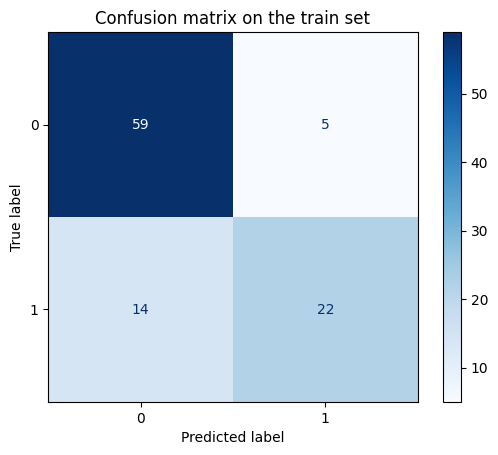

In [77]:
_, ax = plt.subplots()
ax.set(title = "Confusion matrix on the train set")
ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test, ax = ax, cmap = "Blues")
plt.show()

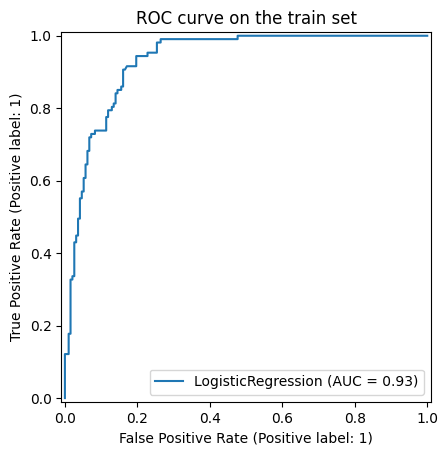

In [85]:
## ROC receiver operator characteristc curve
## it measures the AUC area under the curve btw FP rate and the true positive rate

_, ax = plt.subplots()
ax.set(title = "ROC curve on the train set")
RocCurveDisplay.from_estimator(classifier, X_train, y_train, ax = ax)
plt.show()

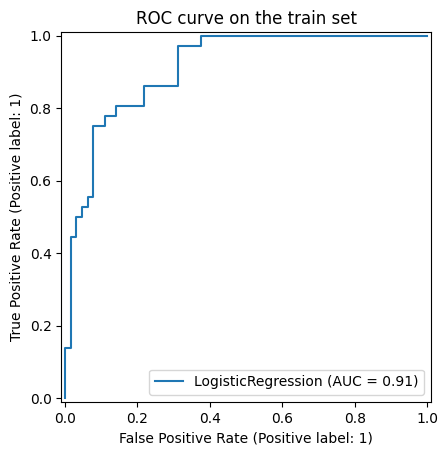

In [86]:
_, ax = plt.subplots()
ax.set(title = "ROC curve on the train set")
RocCurveDisplay.from_estimator(classifier, X_test, y_test, ax = ax)
plt.show()